# Домашнее задание 3. VAE + NF + VAPNEV

В этом задании вам предстоит поработать с набором данных CelebA. Решение домашней работы должно быть представлено в виде .zip архива, содержащего:
- Jupyter Notebook(и) и/или модули с кодом,
- PDF-отчет, в котором необходимо описать проведённые эксперименты, а также обосновать выбор используемых методов (например, дополнительные лоссы для стабилизации, виды потоков, особенности реализации VAE и пр.).

In [1]:
# import yadisk
# def download_extract_dataset_yadisk():
#     y = yadisk.YaDisk()
#     public_url = "https://disk.yandex.ru/d/jSE5WDj3-Wllsg"
#     public_info = y.get_public_meta(public_url)
#     y.download_public(public_url, public_info['name'])

# download_extract_dataset_yadisk()

## Настройка окружения

In [1]:
# import sys
# sys.path.append('../seminars/utils/')  # Добавляем путь к CelebADataset

import torch
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np

from datasets.celeba import CelebADataset

# Set device
cuda = torch.cuda.is_available()
device = torch.device("cpu")
torch.backends.cudnn.benchmark = cuda

print(f"Using device: {device}")

Using device: cpu


### Загрузка данных

In [2]:
# Определение трансформаций

t_normalize = lambda x: x * 2 - 1
t_invnormalize = lambda x: (x + 1) / 2

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    t_normalize,
])

In [3]:
# Кастомный датасет CelebA, возвращающий только изображения

class CelebaCustomDataset(CelebADataset):
    def __getitem__(self, idx):
        image, _ = super().__getitem__(idx)
        return image

dataset = CelebaCustomDataset(
    transform=transform,
    root_dir='../seminars/data/celeba',
)

# Пример получения изображения
img = dataset[0]
print("Размер изображения:", img.shape)

Размер изображения: torch.Size([3, 64, 64])


### Визуализация датасета

In [4]:
def plot_img(img, transform=None):
    if transform:
        img = transform(img)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis('off')

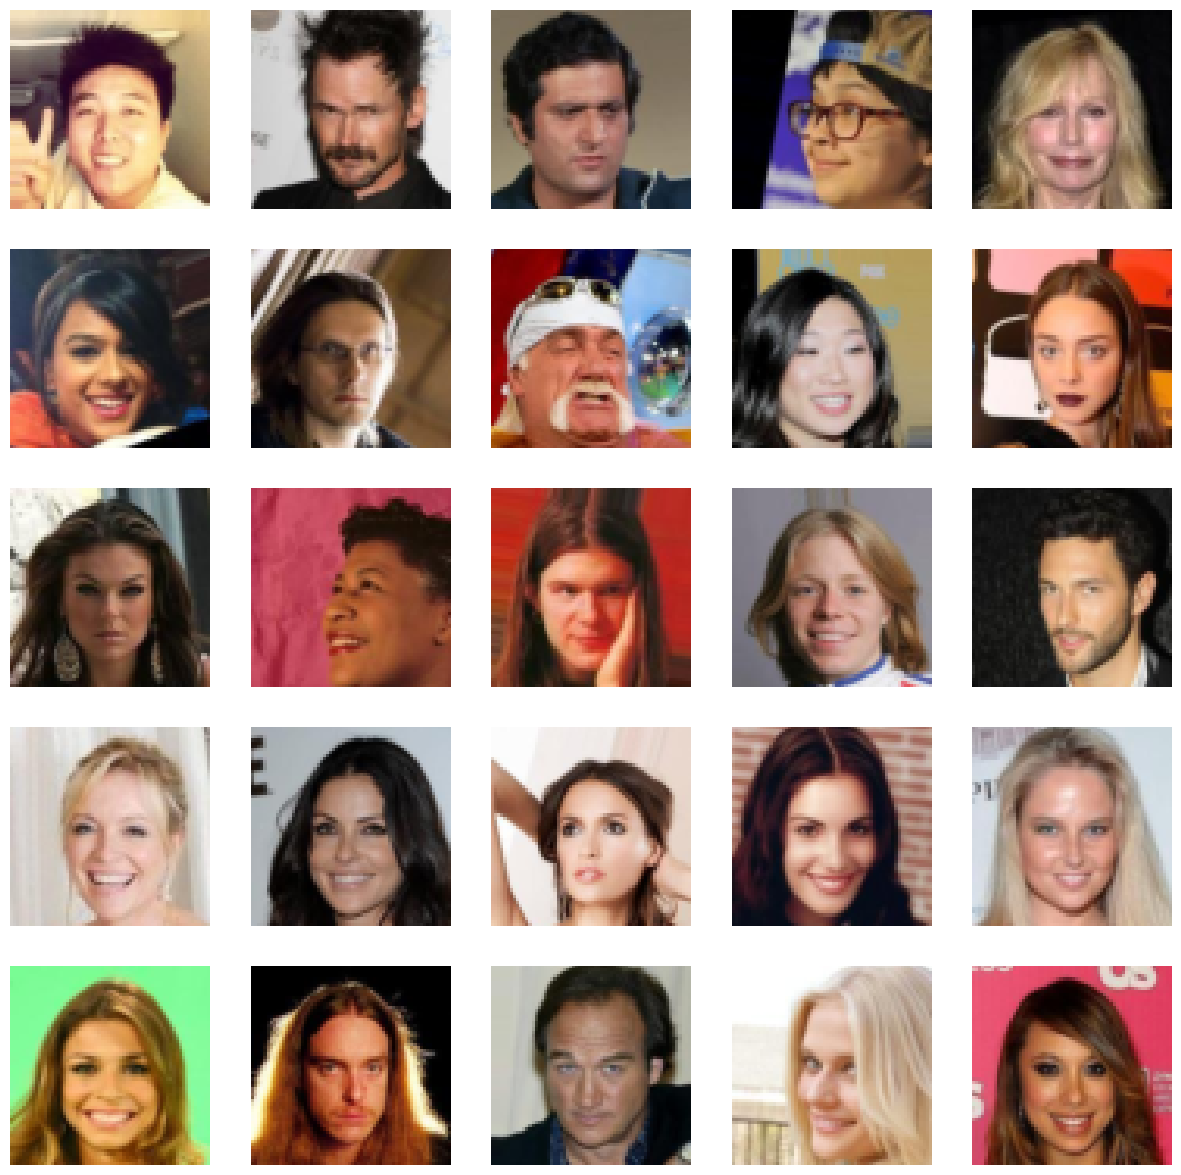

In [5]:
plt.figure(figsize=(15, 15))
for i in range(25):
    random_idx = np.random.randint(len(dataset))
    img = dataset[random_idx]
    plt.subplot(5, 5, i + 1)
    plot_img(img, t_invnormalize)
plt.show()

### Задача 3 (6/10 баллов)

#### Задача 3.1 (4/10 баллов): Построение и обучение VAPNEV на CelebA

Изучите статью [VAPNEV](https://arxiv.org/pdf/1611.05209.pdf), реализуйте и обучите модель до качества, удовлетворяющего базовым порогам (точные пороги будут предоставлены позже). Измерьте FID и сохраните результаты.

#### Задача 3.2 (2/10 баллов): Построение и обучение conditional VAPNEV на CelebA

Реализуйте условный (conditional) вариант VAPNEV. Подробности можно найти в описании задачи и в статье.

In [ ]:
import torch
import torch.nn as nn

class CouplingLayer(nn.Module):
    def __init__(self, in_channels, mid_channels, mask):
        super().__init__()
        self.mask = mask

        self.s = nn.Sequential(
            nn.Linear(in_channels, mid_channels),
            nn.ReLU(),
            nn.Linear(mid_channels, in_channels),
            nn.Tanh()
        )
        self.t = nn.Sequential(
            nn.Linear(in_channels, mid_channels),
            nn.ReLU(),
            nn.Linear(mid_channels, in_channels)
        )

    def forward(self, x, reverse=False):
        x_masked = x * self.mask
        s = self.s(x_masked) * (1 - self.mask)
        t = self.t(x_masked) * (1 - self.mask)

        if not reverse:
            z = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
            log_det = torch.sum(s, dim=1)
        else:
            z = x_masked + (1 - self.mask) * ((x - t) * torch.exp(-s))
            log_det = -torch.sum(s, dim=1)

        return z, log_det

In [7]:
class RealNVP(nn.Module):
    def __init__(self, latent_dim, num_layers, mid_channels):
        super().__init__()
        self.layers = nn.ModuleList()
        mask = torch.arange(latent_dim) % 2  # Alternating mask
        mask = mask.float().view(1, -1).to(device)

        for _ in range(num_layers):
            self.layers.append(CouplingLayer(latent_dim, mid_channels, mask))
            mask = 1 - mask  # Flip mask for next layer

    def forward(self, z, reverse=False):
        log_det = 0
        if not reverse:
            for layer in self.layers:
                z, ld = layer(z)
                log_det += ld
        else:
            for layer in reversed(self.layers):
                z, ld = layer(z, reverse=True)
                log_det += ld
        return z, log_det

In [8]:
class VAE_NVP(nn.Module):
    def __init__(self, latent_dim=64, num_layers=4, mid_channels=256):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # [B, 32, 32, 32]
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # [B, 64, 16, 16]
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*16*16, 512),
            nn.ReLU(),
            nn.Linear(512, 2 * latent_dim)  # μ and log_var
        )

        # RealNVP Flow
        self.flow = RealNVP(latent_dim, num_layers, mid_channels)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 64*16*16),
            nn.ReLU(),
            nn.Unflatten(1, (64, 16, 16)),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encoder
        h = self.encoder(x)
        mu, log_var = torch.chunk(h, 2, dim=1)
        z_base = self.reparameterize(mu, log_var)

        # Apply RealNVP
        z, log_det = self.flow(z_base)

        # Decoder
        x_recon = self.decoder(z)

        return x_recon, mu, log_var, z, log_det
    
    def sample(self, num_samples, temperature=1.0):
        """
        Generate new images by sampling from the latent space
        Args:
            num_samples: Number of images to generate
            temperature: Controls sampling diversity (0-1)
        """
        with torch.no_grad():
            # 1. Sample from base distribution (Gaussian prior)
            z_base = torch.randn(num_samples, self.latent_dim).to(device) * temperature
            
            # 2. Apply forward flow (same direction as training)
            z, _ = self.flow(z_base)
            
            # 3. Decode to image space
            samples = self.decoder(z)
            
        return samples

In [9]:
import torch.nn.functional as F

def vae_nvp_loss(recon_x, x, mean, logvar, logdet):

    batch_size = recon_x.shape[0]

    recon_mse_loss = F.mse_loss(recon_x.view(batch_size, -1), x.view(batch_size, -1), reduction='sum') / batch_size

    # KL Divergence Loss - Normalized per batch
    kld_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - torch.clamp(logvar.exp(), min=1e-8)) / batch_size

    logdet_sum = logdet.sum() / batch_size
    

    return recon_mse_loss + kld_loss - logdet_sum

In [10]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=512,
    num_workers=8,
    pin_memory=True if device.type == 'cuda' else False,
    shuffle=True
)

In [11]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

def visualize_samples(model, num_samples=16):
    model.eval()
    samples = model.sample(num_samples)

    plt.figure(figsize=(15, 15))
    
    for i in range(num_samples):
        img = samples[i].detach().cpu()
        plt.subplot(5, 5, i + 1)
        plot_img(img, t_invnormalize)
        plt.axis('off')
    plt.title('Generated Samples')
    plt.show()


In [12]:
model = VAE_NVP(latent_dim=512).to(device)


In [ ]:
def train_vapnev(model, epochs):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    train_losses = []  # To store average loss per epoch


    for epoch in range(epochs):
        epoch_loss = 0.0  # Track cumulative loss for the epoch
        batch_count = 0
        model.train()
        for batch in dataloader:
            x = batch.to(device)
            x_recon, mu, log_var, z, log_det = model(x)
            loss = vae_nvp_loss(x, x_recon, mu, log_var, log_det)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


            epoch_loss += loss.item()
            batch_count += 1

        # Calculate average epoch loss
        avg_epoch_loss = epoch_loss / batch_count
        train_losses.append(avg_epoch_loss)
            
        clear_output()
        visualize_samples(model, 10)

        plt.plot(train_losses, label='Training Loss', linewidth=2)
        plt.scatter(range(len(train_losses)), train_losses, c='red')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.grid(True)
        plt.legend()
        
        plt.tight_layout()
        plt.show()


        print(f"Epoch {epoch}, Avg_Loss: {avg_epoch_loss}")


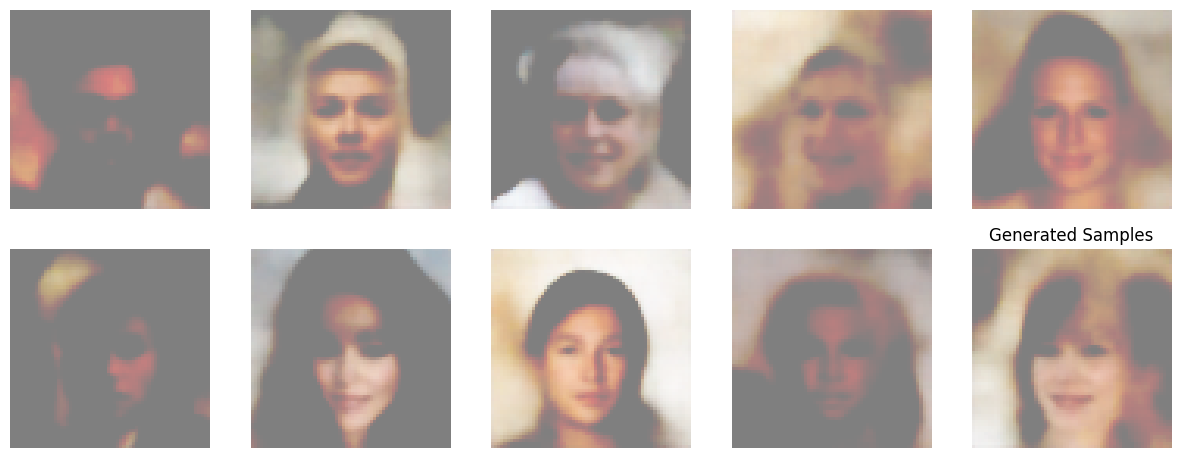

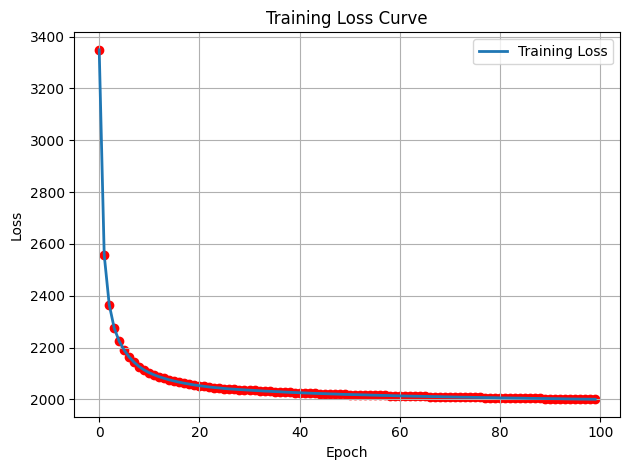

Epoch 99, Loss: 2040.36669921875


In [ ]:
# epochs = 100

# train_vapnev(model, epochs)


In [ ]:
# torch.save(model.state_dict(), './checkpoints/vapnev_mk5.pth')


In [ ]:
model.load_state_dict(torch.load("./checkpoints/vapnev_mk5.pth"))

<All keys matched successfully>

In [ ]:
from utils import FidScore

@torch.no_grad()
def calculate_fid_vapnev(vae: VAE_NVP, num_samples):
    model.eval()
    real_images = torch.stack([dataset[i] for i in range(num_samples)], dim=0).to(device)

    reconstructions, _, _, _, _= vae(real_images)
    fid = FidScore()
    fid(real_images, reconstructions)
    return fid.compute()

In [ ]:
calculate_fid_vapnev(model.cpu(), 10000)

// 7500